# Solving the n-Queens Problem using Local Search

Student Name: Thomas Jones

I have used the following AI tools: Google Gemini, Github Copilot

I understand that my submission needs to be my own work: TJ


## Learning Outcomes

* Implement multiple hill climbing search variants to solve the n-Queens problem.
* Apply simulated annealing with appropriate temperature scheduling to overcome local optima.
* Compare algorithm performance using runtime, solution quality, and success rate metrics.
* Analyze and visualize algorithm performance across different problem sizes.
* Graduate Students: Design and test alternative local move operators to improve search efficiency.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

## The n-Queens Problem

* __Goal:__ Find an arrangement of $n$ queens on a $n \times n$ chess board so that no queen is on the same row, column or diagonal as any other queen.

* __State space:__ An arrangement of the queens on the board. We restrict the state space to arrangements where there is only a single queen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the queens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two queens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ queens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one queen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one queen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum.

## Helper functions

In [195]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

np.random.seed(1234)


def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""

    return(np.random.randint(0,n, size = n))

def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)

    horizontal_cnt = [0] * n
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n

    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1

    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

# decrease the font size to fit larger boards
def show_board(board, cols = ['white', 'gray'], fontsize = 48):
    """display the board"""

    n = len(board)

    # create chess board display
    display = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            if (((i+j) % 2) != 0):
                display[i,j] = 1

    cmap = colors.ListedColormap(cols)
    fig, ax = plt.subplots()
    ax.imshow(display, cmap = cmap,
              norm = colors.BoundaryNorm(range(len(cols)+1), cmap.N))
    ax.set_xticks([])
    ax.set_yticks([])

    # place queens. Note: Unicode u265B is a black queen
    for j in range(n):
        plt.text(j, board[j], u"\u265B", fontsize = fontsize,
                 horizontalalignment = 'center',
                 verticalalignment = 'center')

    print(f"Board with {conflicts(board)} conflicts.")
    plt.show()

## Create a board

Board with 4 conflicts.


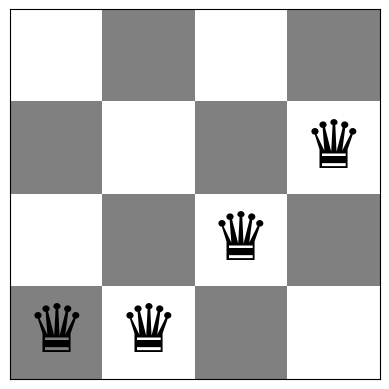

Queens (left to right) are at rows: [3 3 2 1]
Number of conflicts: 4


In [196]:
board = random_board(4)

show_board(board)
print(f"Queens (left to right) are at rows: {board}")
print(f"Number of conflicts: {conflicts(board)}")

A board $4 \times 4$ with no conflicts:

Board with 0 conflicts.


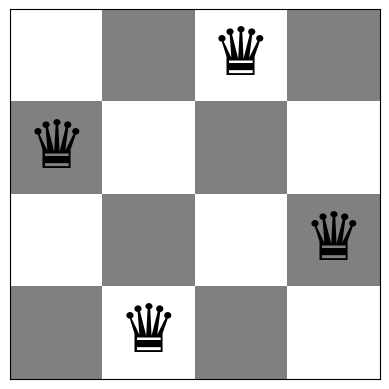

In [197]:
board = [1,3,0,2]
show_board(board)

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. Sync your forked repository and pull the latest revision.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Steepest-ascend Hill Climbing Search [20 Points]

Calculate the objective function for all local moves (see definition of local moves above) and always choose the best among all local moves. If there are no local moves that improve the objective, then you have reached a local optimum.

In [198]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

def steepest_ascent(board, max_iterations = 1000):
  """Steepest ascent hill climbing search. Always move to the best neighbor."""
  current = board.copy()
  current_conflicts = conflicts(current)
  history = [current_conflicts]

  for i in range(max_iterations):
    best_board = current.copy()
    best_conflicts = current_conflicts
    improved = False

    #Try every possible move
    for col in range(len(current)):
      original_row = current[col]
      for row in range(len(current)):
        if row == original_row:
          continue
        current[col] = row
        new_conflicts = conflicts(current)
        if new_conflicts < best_conflicts:
          best_board = current.copy()
          best_conflicts = new_conflicts
          improved = True

      current[col] = original_row #Reset

    current = best_board
    current_conflicts = best_conflicts
    history.append(current_conflicts)

    if current_conflicts == 0 or not improved:
      break

  return current, current_conflicts, history


This implements classic steepest-ascent hill climbing. In each step we check all possible local moves and choose the one that gives the largest reduction in conflicts. it stops when no improving move exists or a solution is found.

## Task 2: Inefficient Stochastic Hill Climbing [10 Points]

Modify the algorithm for steepest-ascend hill climbing by choosing randomly from among all uphill moves till you have reached a local optimum.

In [199]:
def inefficient_stochastic(board, max_iterations = 1000):
  """Inefficient stochastic hill climbing: randomly pick among all improving moves"""
  current = board.copy()
  current_conflicts = conflicts(current)
  history = [current_conflicts]

  for i in range(max_iterations):
    neighbors = []
    for col in range(len(current)):
      original_row = current[col]
      for row in range(len(current)):
        if row == original_row:
          continue
        current[col] = row
        new_conflicts = conflicts(current)
        if new_conflicts < current_conflicts:
          neighbors.append((current.copy(), new_conflicts))
      current[col] = original_row

    if not neighbors:
      break # No improving move exists

    #Pick randomly among improving neighbors
    current, current_conflicts = neighbors[np.random.randint(len(neighbors))]
    history.append(current_conflicts)

    if current_conflicts == 0:
      break #optimal solution

  return current, current_conflicts, history

This is the inefficient version because it still generates all improving neighbors every iteration and then picks one at random. it produces the same behavior as steepest-ascent on average but with more randomness.

__Important note:__ This is a very expensive algorithm since it has to calculate the objective function (number of conflicts) for all possible moves. The next algorithm produces the same result, but with much less computational cost.

## Task 3: Efficient Stochastic Hill Climbing [20 Points]

Stochastic hill climbing is in practice always implemented in the following way:

1. Generate only a single random local neighbor at a time.
2. Accept the move if it has a better objective function value than the current state.
3. Repeat till a stopping criterion is met.

This is very efficient if each state has many possible successor states. This method is called "First-choice hill climbing" in the textbook and in practice this is just called "Stochastic Hill Climbing."

__Notes:__

* Detecting local optima is tricky since you never calculate the objective function for all local moves! A popular option is to stop if you were not able to improve the objective function during the last $x$ tries. You will need to argue what the right number for $x$ is. It will depend on the size of the board. Hint: You are sampling random local moves from the set of all possible moves with replacement and you want to make sure that you trie almost all before you stop.

In [200]:
def efficient_stochastic(board, no_improvement_factor=3):
  """Efficient stochastic hill climbing: generate one neighbor at a time"""
  board = list(board)
  n = len(board)
  total_moves = n * (n-1)
  max_no_improvements = no_improvement_factor * total_moves * max(1,int(np.log(total_moves+1)))

  history = [conflicts(board)]
  no_improve_count = 0

  while no_improve_count < max_no_improvements:
    #Random local move, random column and different random row
    col = np.random.randint(n)
    row = np.random.randint(n-1)
    if row >= board[col]:
      row += 1 #Skip

    original_row = board[col]
    board[col] = row
    new_conflicts = conflicts(board)
    if new_conflicts < history[-1]:
      history.append(new_conflicts)
      if new_conflicts == 0:
        break #Optimal

    else: #Revert
      board[col] = original_row
      no_improve_count += 1

  return board, conflicts(board), history

We only evaluate one random neighbor per iteration. We accept it only if it improves the objective. Stops when no improvement is found because for an nxn board, there are n*(n-1) total local moves and to sample almost all with replacement we need n*(n-1) * ln(n*(n-1)) tries. I used a factor of 3 as a multiplier.

## Task 4: Hill Climbing Search with Random Restarts [10 Points]

Hill climbing will often end up in local optima. Restart the each of the three hill climbing algorithm up to 100 times with a random board to find a better (hopefully optimal) solution. Note that restart just means to run the algorithm several times starting with a new random board.

Steepest Ascent found a solution with 0 conflicts after 5 restarts
Inefficient Stochastic found a solution with 0 conflicts after 5 restarts
Efficient Stochastic found a solution with 0 conflicts after 12 restarts
Board with 0 conflicts.


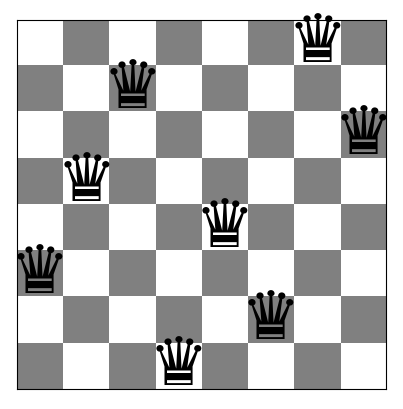

In [201]:
def hill_climbing_with_restarts(n, algorithm, max_restarts=100):
  """Runs any hill-climbing algorithm up to max_restarts times with a random board"""

  best_board = None
  best_conflicts = float('inf')

  for restart in range(max_restarts):
    board = random_board(n)
    result, c, i = algorithm(board) #Ignores history
    if c < best_conflicts:
      best_board = result
      best_conflicts = c
    if best_conflicts == 0: #Stop if solution found
      return best_board, best_conflicts, restart+1

  return best_board, best_conflicts, max_restarts

# Test with restarts for different Algos
algorithms = {
    "Steepest Ascent": steepest_ascent,
    "Inefficient Stochastic": inefficient_stochastic,
    "Efficient Stochastic": efficient_stochastic,
}

for name, algorithm in algorithms.items():
  board, c, restarts = hill_climbing_with_restarts(8, algorithm, max_restarts=100)
  print(f"{name} found a solution with {c} conflicts after {restarts} restarts")

#Final board from steepest ascent with restarts
board, c, restarts = hill_climbing_with_restarts(8, steepest_ascent, max_restarts=100)
show_board(board)

Runs any hill-climbing algorithm up to max_restarts times with random boards. Returns the solution with the lowest amount of conflicts found. Takes in board size, type of algorithm and maximum number of random restarts. Returns best board with the lowest amount of conflicts and number of restarts used.

## Task 5: Simulated Annealing [10 Points]

Simulated annealing is a form of efficient stochastic hill climbing that avoid local optima by also allowing downhill moves with a probability proportional to a temperature. The temperature is decreased in every iteration following an annealing schedule. You have to experiment with the annealing schedule (Google to find guidance on this).


1. Implement simulated annealing for the n-Queens problem.
2. Create a visualization of the search process (a line chart of how the number if conflict changes as the algorithm progresses).
3. Use this visualization for experiments with different choices for the annealing schedule and discuss what you have learned.

Found a solution with 0 conflicts and 349 or iterations


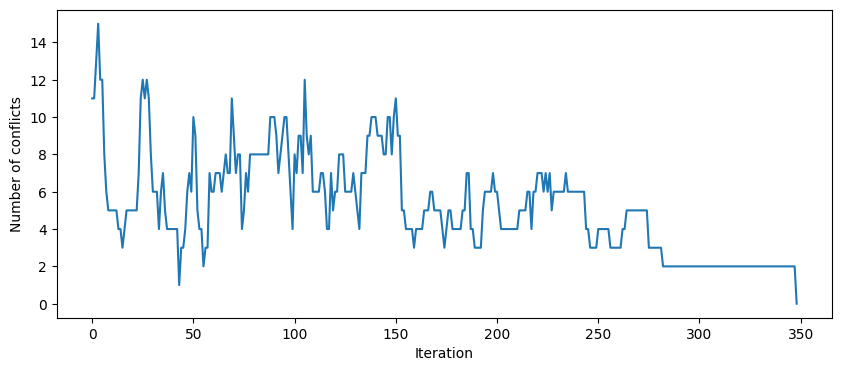

Board with 0 conflicts.


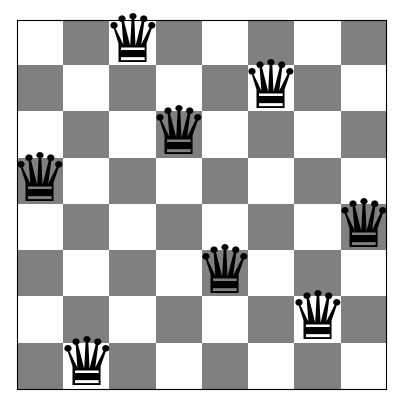

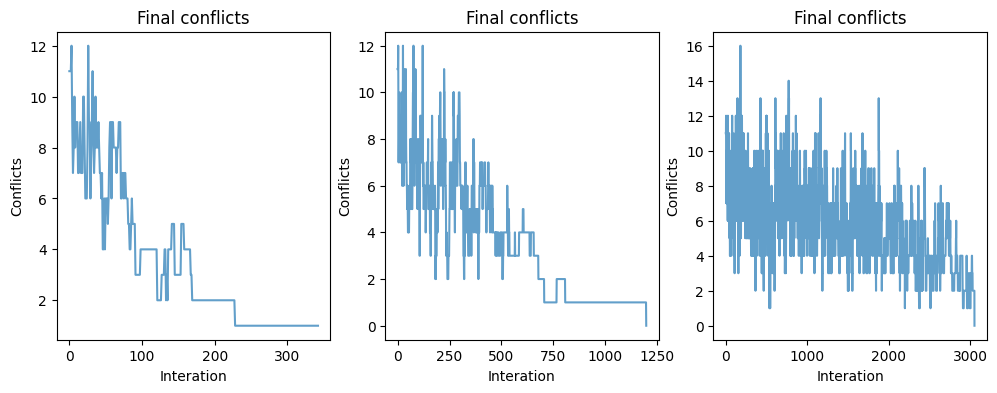

In [202]:
from IPython.core import history
def simulated_annealing(board, T_start = 10.0, T_end = 0.01, alpha = 0.99):
  """Simulated annealing search for n-Queens
  Annealing schedule t_{k+1} = t_k * alpha
  T_start: initial temperature
  T_end: final temperature
  alpha: temperature decay rate
  """

  board = list(board)
  n=len(board)
  current_conflicts = conflicts(board)
  best_board = list(board)
  best_conflicts = current_conflicts
  history = [current_conflicts]
  T = T_start

  while T > T_end:
    #random local move (one queens row)
    col = np.random.randint(n)
    row = np.random.randint(n-1)
    if row >= board[col]:
      row += 1
    original_row = board[col]
    board[col] = row
    new_conflicts = conflicts(board)
    delta = new_conflicts - current_conflicts
    # Accept better moves or worse moves with probability (-delta/T)
    if delta < 0 or np.random.rand() < np.exp(-delta/T):
      current_conflicts = new_conflicts
      if current_conflicts < best_conflicts:
        best_board = list(board)
        best_conflicts = current_conflicts
    else:
      board[col] = original_row # revert

    history.append(current_conflicts)
    T *= alpha
    if best_conflicts == 0:
      break

  return best_board, best_conflicts, history

# test on random board
np.random.seed(12)
board = random_board(8)
result, c, history = simulated_annealing(board)
print(f"Found a solution with {c} conflicts and {len(history)} or iterations")

plt.figure(figsize=(10, 4))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel("Number of conflicts")
plt.show()

show_board(result)

# different cooling schedules
schedules = [
    ("Fast (a=0.98)",   dict(T_start=10, T_end=0.01, alpha=0.98)),
    ("Medium (a=0.995)", dict(T_start=10, T_end=0.01, alpha=0.995)),
    ("Slow (a=0.999)",  dict(T_start=10, T_end=0.01, alpha=0.999)),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (label, params) in zip(axes, schedules):
  np.random.seed(0)
  _, c, history = simulated_annealing(board, **params)
  ax.plot(history, alpha=0.7)
  ax.set_title("Final conflicts")
  ax.set_xlabel("Interation")
  ax.set_ylabel("Conflicts")
plt.show()



Slower cooling allows more thorough exploration and consistently reaches 0 conflicts, but requires more iterations. Fast cooling can get trapped in local optima and alpha = 0.995 is a example of good balance.

## Task 6: Algorithm Behavior Analysis [20 Points]

### Comparison
Compare the algorithm using runtime and objective function values. Use boards of size 4 and 8 to explore how the different algorithms perform. Make sure that you run the algorithms for each board size several times (at least 100 times) with different starting boards and report averages.

Complete the following table

| Algorithm            | Board size | Avg. Run time | Avg. number of conflicts | % of runs ending in optimal solution  |
| -------------------- | ---------- | ------------- | --------------------------------- | - |
| Steepest asc. HC     |     4      |0.0002               |0.73                                   |34%   |
| Ineff. Stochastic HC |     4      |0.0003               |0.75                                   |38%   |
| Efficient Stochastic HC |     4      |0.0013               |0.8                                   |36%   |
| Simulated Annealing  |     4      |0.0013               |0.0                                   |100%   |
| Steepest asc. HC     |     8      |0.0027               |1.38                                   |8%   |
| Ineff. Stochastic HC |     8      |0.0045               |1.2                                   |19%   |
| Efficient Stochastic HC |     8      |0.0029               |1.45                                   |6%   |
| Simulated Annealing  |     8      |0.0096               |0.46                                   |55%   |

Hint: See [Profiling Python Code](../HOWTOs/profiling_code.ipynb) for help about how to measure runtime in Python.

Add the used code here:

In [203]:
import time

def comparison(algorithm, n, iterations = 100, **kwargs):
  """ Runs an algorithm interations times on random boards.
  Returns the average run time and conflicts and success rate
  """
  times, final_conflicts = [], []
  for i in range(iterations):
    board = random_board(n)
    start = time.perf_counter()
    if kwargs: # call algorithm with or without extra kwargs
      result, c, _ = algorithm(board, **kwargs)
    else:
      result, c, _ = algorithm(board)
    elapsed = time.perf_counter() - start
    times.append(elapsed)
    final_conflicts.append(c)
  return (
      np.mean(times),
      np.mean(final_conflicts),
      100 * np.mean(np.array(final_conflicts) == 0)
  )

algorithms = [
    ("Steepest-ascent", steepest_ascent, {}),
    ("Inefficient Stochastic", inefficient_stochastic, {}),
    ("Efficient Stochastic", efficient_stochastic, {}),
    ("Simulated Annealing", simulated_annealing, {}),
]

iterations = 100

results = {}
for n in [4, 8]:
  for name, algorithm, kwargs in algorithms:
    avg_time, avg_conflicts, success_rate = comparison(algorithm, n, iterations, **kwargs)
    print(f"{name} {n} {avg_time:>12.4f} {avg_conflicts} {success_rate}")
    results[(name,n)] = (avg_time, avg_conflicts, success_rate)
  print()

Steepest-ascent 4       0.0002 0.68 37.0
Inefficient Stochastic 4       0.0002 0.86 35.0
Efficient Stochastic 4       0.0009 0.96 26.0
Simulated Annealing 4       0.0014 0.0 100.0

Steepest-ascent 8       0.0027 1.37 12.0
Inefficient Stochastic 8       0.0040 1.2 14.000000000000002
Efficient Stochastic 8       0.0094 1.22 14.000000000000002
Simulated Annealing 8       0.0148 0.49 51.0



### Algorithm Convergence

For each algorithm implemented, describe the typical convergence pattern (fast initial improvement vs. steady progress).
Include a plot showing the objective function value over iterations for one representative run of each algorithm on the 8-queens problem.
Explain which algorithms exhibit plateaus or getting stuck in local optima most frequently.

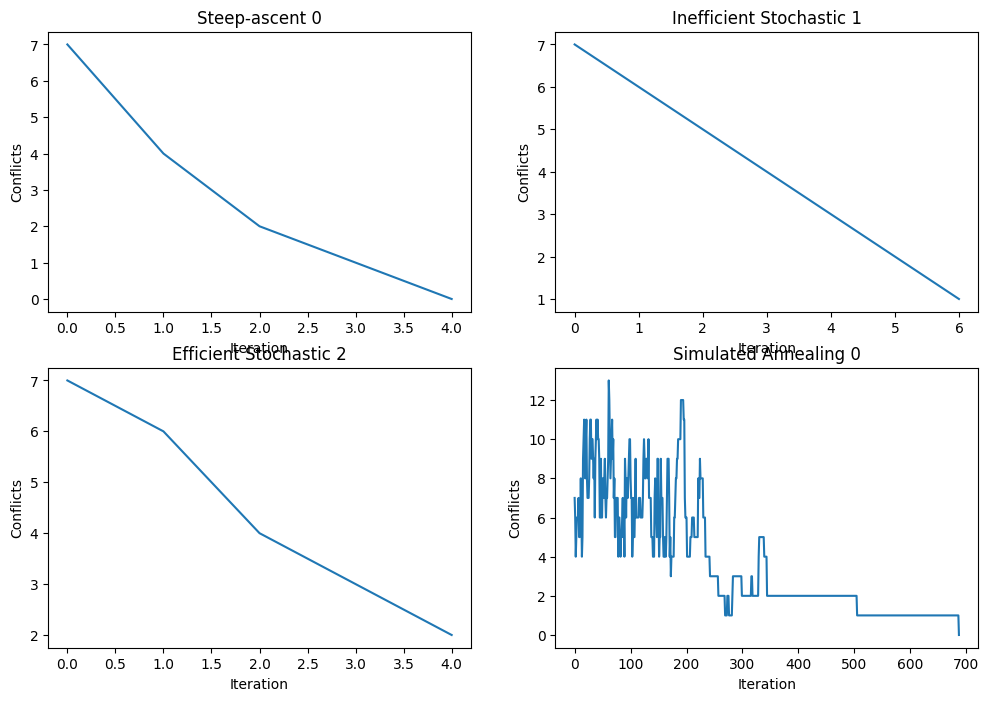

In [204]:
np.random.seed(7)
board8 = random_board(8) #Create random starting board

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # for display of convergence curves
axes = axes.flatten()

algorithms = [
    ("Steep-ascent", steepest_ascent, {}),
    ("Inefficient Stochastic", inefficient_stochastic, {}),
    ("Efficient Stochastic", efficient_stochastic, {}),
    ("Simulated Annealing", simulated_annealing, {}),
]

# Plot convergence history for each algo on the same starting random board
for ax, (name, algorithm, kwargs) in zip(axes, algorithms):
  np.random.seed(7)
  board = random_board(8)
  _, final_c, history = algorithm(board, **kwargs)
  ax.plot(history)
  ax.set_title(f"{name} {final_c}")
  ax.set_xlabel("Iteration")
  ax.set_ylabel("Conflicts")
plt.show()

Steepest-ascent hill climbing drops quickly at first but then plateaus at a local optimim. Inefficient Stochastic hill climbing has a similar profile but the random selection among uphill moves brings a slight variation in each run. Efficient Stochastic hill climbing makes sporadic improvements, the flat stretches reflect rejected random moves, so the x-axis counts improving steps only. Simulated Annealing shows noisy behavior early that smooths as temp falls, often reaching 0 conflicts that other hill climbing algorithms miss.

### Problem Size Scalability

Create a log-log plot showing how runtime scales with board size ($n=4, 8, 12, 16, 20$) for at least two algorithms.
Estimate the empirical time complexity (Big O) for each algorithm based on your results.
Identify which algorithm scales best for large problem sizes and explain why.

Steepest-ascent 3.30 (O(n^3.30))
Efficient Stochastic 2.98 (O(n^2.98))


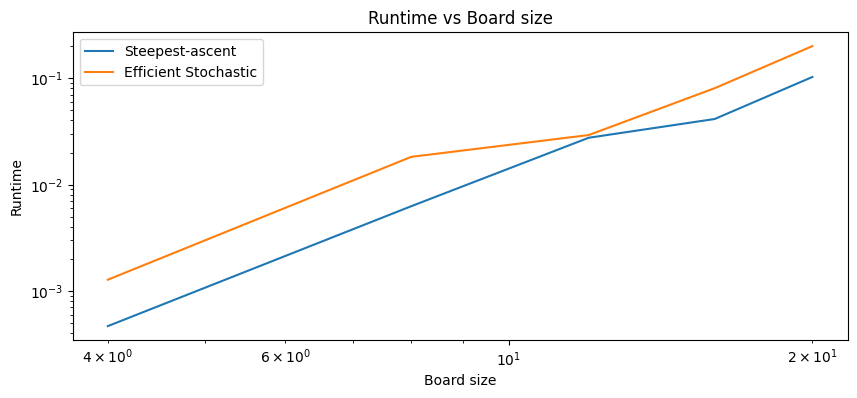

In [205]:
sizes = [4, 8, 12, 16, 20]

SCALE = 30 #Number or repeated runs per board size

# Dictionary to store average runtimes for each algo
scale_results = {name: [] for name in ["Steepest-ascent", "Efficient Stochastic"]}

for n in sizes:
  #Test each algo on current board size
  for name, algorithm, kwargs in [
      ("Steepest-ascent", steepest_ascent, {}),
      ("Efficient Stochastic", efficient_stochastic, {}),
  ]:
      times =[]
      for i in range(SCALE):
        board = random_board(n)
        start = time.perf_counter()
        algorithm(board, **kwargs)
        times.append(time.perf_counter() - start)
      scale_results[name].append(np.mean(times)) #Store average runtimes

log_n = np.log(sizes) # Log of board sizes
for name, times in scale_results.items():
  log_time = np.log(times)
  slope, intercept = np.polyfit(log_n, log_time, 1)
  print(f"{name} {slope:.2f} (O(n^{slope:.2f}))")

plt.figure(figsize=(10, 4))
for name, times in scale_results.items():
  plt.plot(sizes, times, label=name)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Board size")
plt.ylabel("Runtime")
plt.title("Runtime vs Board size")
plt.legend()
plt.show()

Steepest-ascent hill climbing evaluates all n*(n-1) moves at every step, giving at least O(n^3) per run, visible as a steeper log-log slope. Efficient Stochasic hill climbing samples moves one at a time, so its per-step cost is O(1) conflict evaluation and the total work grows more slowly with n. For large boards Efficient Stochastic hill climbing scales much better but it may need random restarts to reliably reach an optimal solution.

In [206]:
!jupyter nbconvert --to html /content/n_queens.ipynb

[NbConvertApp] Converting notebook /content/n_queens.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 701441 bytes to /content/n_queens.html


## Advanced task: Exploring other Local Moves Operators

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### Move Operator Implementation

Implement the following local move operators:

* Single-step move: Move one queen only one square up or down at a time
* Column swap: Exchange the positions of queens in two randomly selected columns
* Dual-queen move: Select two queens and move both simultaneously
* Adaptive move: Design your own operator that adapts which local move it uses based on the current state (e.g., focuses on queens with most conflicts or randomly chooses one of the moves above)

### Experimental Analysis

Using the 8-Queens and 12-Queens problems: Run your __Efficient Stochastic Hill Climbing__ implementation with each move operator 100 times.

For each operator, create a visualization showing:

* Average solution quality over iterations
* Distribution of final solution qualities
* Average time to solution for successful runs

### Discussion

Describe what you have learned from the experiments. Which operator works best for which situation and why?

In [207]:
# Code and description go here

## More Things to Do (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Implement a Genetic Algorithm for the n-Queens problem

In [208]:
# Code and description go here